<a href="https://colab.research.google.com/github/SikandarHussain6858/BigDataAnalyticslabs/blob/main/lab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CS-404 Lab 03: Exploratory Data Analysis and Pattern Discovery

## **Muhammad Sikandar Hussain 502808**

## Setup

In [ ]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.float_format', lambda value: f'{value:,.2f}')
plt.style.use('seaborn-v0_8-whitegrid')

# This works when the notebook is opened from the lab3 folder, repository root,
# or Google Colab after the CSV has been uploaded to /content.
possible_paths = [
    Path('Lab03_Ecommerce_Orders.csv'),
    Path('lab3/Lab03_Ecommerce_Orders.csv'),
    Path('/content/Lab03_Ecommerce_Orders.csv'),
]
data_path = next((path for path in possible_paths if path.exists()), None)
if data_path is None:
    raise FileNotFoundError('Upload or place Lab03_Ecommerce_Orders.csv beside this notebook.')

print(f'Dataset path: {data_path.resolve()}')

Dataset path: D:\code\BigDataAnalytics\lab3\Lab03_Ecommerce_Orders.csv


## Guided Sample: From Orders to a Simple Insight

### Step 1: Load and inspect the first 25 records

In [ ]:
df = pd.read_csv(data_path)
sample = df.head(25).copy()
display(sample.head())
print('Shape:', sample.shape)

,order_id,customer_id,order_date,city,region,product_category,product_name,unit_price,quantity,discount_percent,payment_method,delivery_days,customer_rating,returned,total_amount
0,O00001,C0589,2025-08-11,Karachi,Sindh,Books,Study Planner,818.46,2,5,Cash on Delivery,4,4,No,"1,555.07"
1,O00002,C0824,2026-01-03,Rawalpindi,Punjab,Beauty,Skin Care Set,"4,706.16",5,15,Cash on Delivery,4,5,No,"20,001.18"
2,O00003,C0077,2025-11-07,Islamabad,Capital,Fashion,Sneakers,"6,112.36",3,25,Easypaisa/JazzCash,1,4,No,"13,752.81"
3,O00004,C0560,2025-07-29,Peshawar,Khyber Pakhtunkhwa,Fashion,Casual Shirt,"2,619.08",2,5,Cash on Delivery,2,5,No,"4,976.25"
4,O00005,C0108,2025-05-05,Lahore,Punjab,Groceries,Coffee Pack,"1,635.56",2,20,Easypaisa/JazzCash,4,5,No,"2,616.90"


Shape: (25, 15)


**Observation:** The guided sample contains 25 rows and all 15 original dataset columns. Each row represents one order and includes customer, product, payment, delivery, rating, return, and monetary information.

### Step 2: Summarize the sample

In [ ]:
display(sample[['unit_price', 'quantity', 'discount_percent', 'total_amount']].describe())
display(sample['product_category'].value_counts().rename('order_count'))
display(sample['payment_method'].value_counts().rename('order_count'))

,unit_price,quantity,discount_percent,total_amount
count,25.00,25.00,25.00,25.00
mean,"4,005.40",2.16,11.20,"8,079.65"
std,"2,520.39",1.07,8.33,"7,303.15"
min,818.46,1.00,0.00,742.36
25%,"2,082.65",1.00,5.00,"2,616.90"
50%,"3,263.71",2.00,10.00,"6,114.90"
75%,"5,682.20",3.00,15.00,"9,992.03"
max,"11,788.12",5.00,30.00,"31,827.92"


product_category
Beauty            7
Fashion           6
Groceries         5
Books             2
Sports            2
Electronics       2
Home & Kitchen    1
Name: order_count, dtype: int64

payment_method
Cash on Delivery      13
Debit/Credit Card      7
Easypaisa/JazzCash     4
Bank Transfer          1
Name: order_count, dtype: int64

**Observation:** In the first 25 orders, Beauty is the most common category (7 orders), and Cash on Delivery is the most common payment method (13 orders). The sample's median order amount is PKR 6,114.90, while its maximum is PKR 31,827.92.

### Step 3: Aggregate a business question

In [ ]:
sample_category_sales = (sample.groupby('product_category')['total_amount']
                         .sum().sort_values(ascending=False))
display(sample_category_sales.to_frame('revenue_pkr'))
print('Top category:', sample_category_sales.index[0])

,revenue_pkr
product_category,
Beauty,"72,358.56"
Fashion,"55,842.46"
Home & Kitchen,"31,827.92"
Electronics,"17,083.90"
Groceries,"16,412.47"
Sports,"6,168.48"
Books,"2,297.43"


Top category: Beauty


**Observation:** Beauty produces the most revenue in the 25-order sample at PKR 72,358.56, followed by Fashion at PKR 55,842.46.

### Step 4: Visualize and interpret

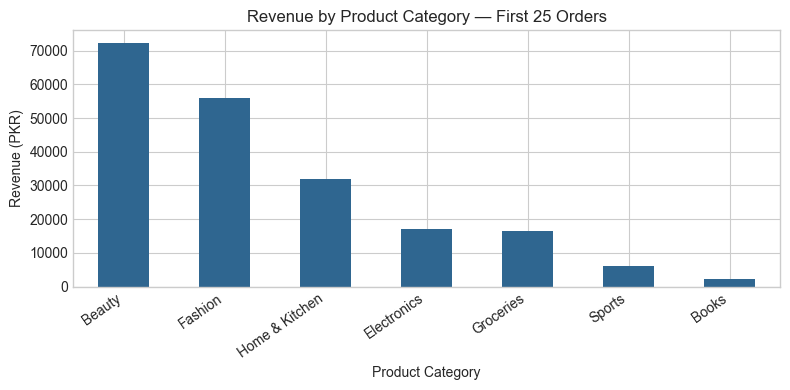

In [ ]:
ax = sample_category_sales.plot(kind='bar', figsize=(8, 4), color='#2F6690')
ax.set_title('Revenue by Product Category — First 25 Orders')
ax.set_xlabel('Product Category')
ax.set_ylabel('Revenue (PKR)')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

**Interpretation:** Beauty is the strongest category in the sample: its PKR 72,358.56 revenue is about 30% higher than Fashion, the second-ranked category. Because this is only a 25-row sample, the full dataset is needed before generalizing the result.

# Task 1: Explore and Describe the Orders

### 1.1 Load the full file and report shape, columns, and order-date range

In [ ]:
orders = pd.read_csv(data_path)
orders['order_date'] = pd.to_datetime(orders['order_date'])

print('Shape:', orders.shape)
print('Columns:', orders.columns.tolist())
print('Order-date range:', orders['order_date'].min().date(), 'to', orders['order_date'].max().date())

Shape: (6000, 15)
Columns: ['order_id', 'customer_id', 'order_date', 'city', 'region', 'product_category', 'product_name', 'unit_price', 'quantity', 'discount_percent', 'payment_method', 'delivery_days', 'customer_rating', 'returned', 'total_amount']
Order-date range: 2025-01-01 to 2026-08-31


**Observation:** The file contains **6,000 orders and 15 columns**, with order dates from **1 January 2025 to 31 August 2026**.

### 1.2 Descriptive statistics

In [ ]:
numeric_summary = orders[['unit_price', 'quantity', 'discount_percent', 'total_amount']].describe()
display(numeric_summary)

,unit_price,quantity,discount_percent,total_amount
count,"6,000.00","6,000.00","6,000.00","6,000.00"
mean,"4,532.13",2.54,12.37,"9,898.92"
std,"3,073.38",1.26,8.80,"8,792.34"
min,724.27,1.00,0.00,550.71
25%,"2,369.94",2.00,5.00,"4,154.28"
50%,"3,435.57",2.00,10.00,"7,253.34"
75%,"6,192.87",3.00,20.00,"12,681.81"
max,"18,461.97",8.00,30.00,"86,006.88"


**Observation:** The average order value is **PKR 9,898.92**, while the median is **PKR 7,253.34**, so high-value orders pull the mean upward. A typical order contains 2–3 items; discounts have a median of 10% and range from 0% to 30%.

### 1.3 Three most common product categories and payment methods

In [ ]:
top_categories = orders['product_category'].value_counts().head(3)
top_payments = orders['payment_method'].value_counts().head(3)

print('Top three product categories:')
display(top_categories.rename('order_count').to_frame())
print('Top three payment methods:')
display(top_payments.rename('order_count').to_frame())

Top three product categories:


,order_count
product_category,
Electronics,1173
Fashion,1059
Groceries,897


Top three payment methods:


,order_count
payment_method,
Cash on Delivery,2516
Debit/Credit Card,1730
Easypaisa/JazzCash,1382


**Two short observations:**

1. **Electronics** is the most frequent product category with **1,173 orders (19.55%)**, followed by Fashion with 1,059 and Groceries with 897.
2. **Cash on Delivery** dominates payment choice with **2,516 orders (41.93%)**; Debit/Credit Card (1,730) and Easypaisa/JazzCash (1,382) are the next most common methods.

# Task 2: Analyze Groups and Customer Behaviour

### 2.1 Total revenue by product category and average order value by region

In [ ]:
revenue_by_category = (orders.groupby('product_category')['total_amount']
                       .sum().sort_values(ascending=False))
region_aov = (orders.groupby('region')['total_amount']
              .mean().sort_values(ascending=False))

print('Total revenue by product category:')
display(revenue_by_category.rename('revenue_pkr').to_frame())
print('Average order value by region:')
display(region_aov.rename('average_order_value_pkr').to_frame())

Total revenue by product category:


,revenue_pkr
product_category,
Electronics,"15,411,021.58"
Home & Kitchen,"14,068,389.08"
Fashion,"9,349,700.77"
Beauty,"8,171,233.78"
Sports,"5,987,947.19"
Groceries,"3,939,738.64"
Books,"2,465,474.49"


Average order value by region:


,average_order_value_pkr
region,
Khyber Pakhtunkhwa,"10,370.28"
Balochistan,"10,149.40"
Punjab,"9,889.26"
Capital,"9,867.76"
Sindh,"9,672.59"


### 2.2 Return rate by product category

In [ ]:
orders['returned_flag'] = orders['returned'].eq('Yes')
return_rate_by_category = (orders.groupby('product_category')['returned_flag']
                           .mean().mul(100).sort_values(ascending=False))
display(return_rate_by_category.rename('return_rate_percent').to_frame())
print(f'Highest return-rate category: {return_rate_by_category.index[0]} '
      f'({return_rate_by_category.iloc[0]:.2f}%)')

,return_rate_percent
product_category,
Fashion,8.40
Beauty,7.45
Electronics,7.16
Books,6.64
Sports,4.93
Home & Kitchen,4.84
Groceries,4.79


Highest return-rate category: Fashion (8.40%)


### 2.3 Top five customers by total spending

In [ ]:
top_customers = (orders.groupby('customer_id')['total_amount']
                 .sum().sort_values(ascending=False).head(5))
display(top_customers.rename('total_spending_pkr').to_frame())

,total_spending_pkr
customer_id,
C0001,"822,364.21"
C0003,"581,863.56"
C0002,"567,897.92"
C0010,"424,277.86"
C0005,"414,595.04"


**Interpretation:** Electronics earns the most revenue (**PKR 15,411,021.58**), while Khyber Pakhtunkhwa has the highest regional average order value (**PKR 10,370.28**). Fashion has the highest return rate (**8.40%**), suggesting that its strong sales activity should be reviewed alongside possible size, fit, or expectation issues. Customer **C0001** is the highest-spending customer at **PKR 822,364.21**.

# Task 3: Visualize Trends and Relationships

### 3.1 Bar chart: total revenue by product category

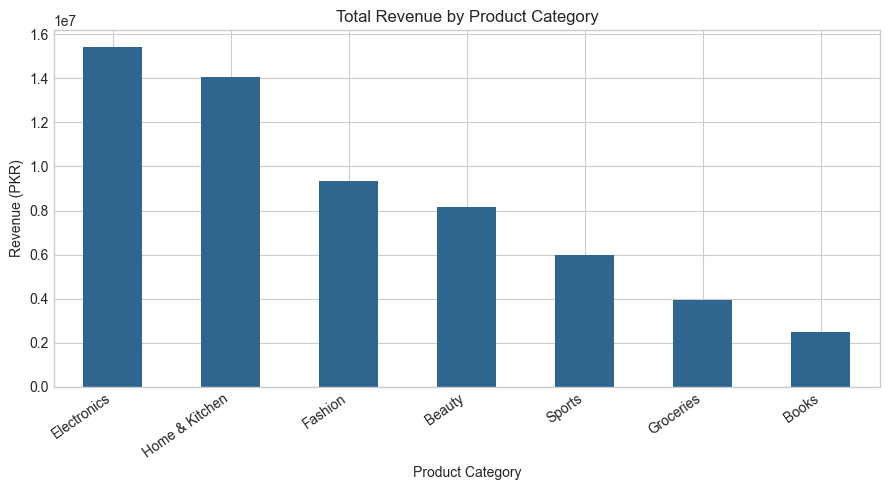

In [ ]:
ax = revenue_by_category.plot(kind='bar', figsize=(9, 5), color='#2F6690')
ax.set_title('Total Revenue by Product Category')
ax.set_xlabel('Product Category')
ax.set_ylabel('Revenue (PKR)')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

### 3.2 Line chart: monthly revenue

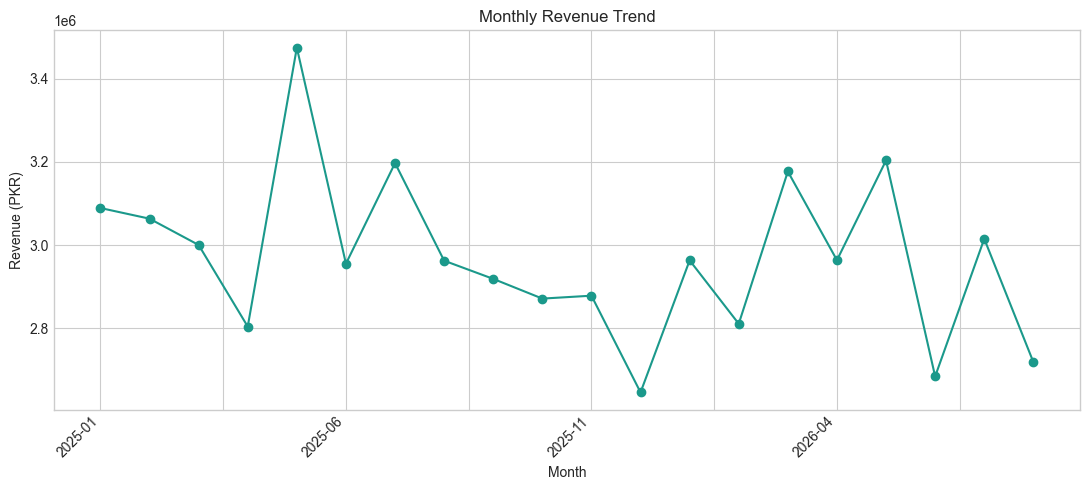

,revenue_pkr
month,
2025-01,"3,088,973.17"
2025-02,"3,063,310.14"
2025-03,"3,000,105.97"
2025-04,"2,803,856.57"
2025-05,"3,474,650.06"
2025-06,"2,955,072.39"
2025-07,"3,197,037.71"
2025-08,"2,962,297.35"
2025-09,"2,918,551.08"


In [ ]:
monthly = (orders.assign(month=orders['order_date'].dt.to_period('M').astype(str))
           .groupby('month')['total_amount'].sum().sort_index())

ax = monthly.plot(kind='line', marker='o', figsize=(11, 5), color='#1B998B')
ax.set_title('Monthly Revenue Trend')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue (PKR)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

display(monthly.rename('revenue_pkr').to_frame())

### 3.3 Scatter plot: discount percentage versus quantity

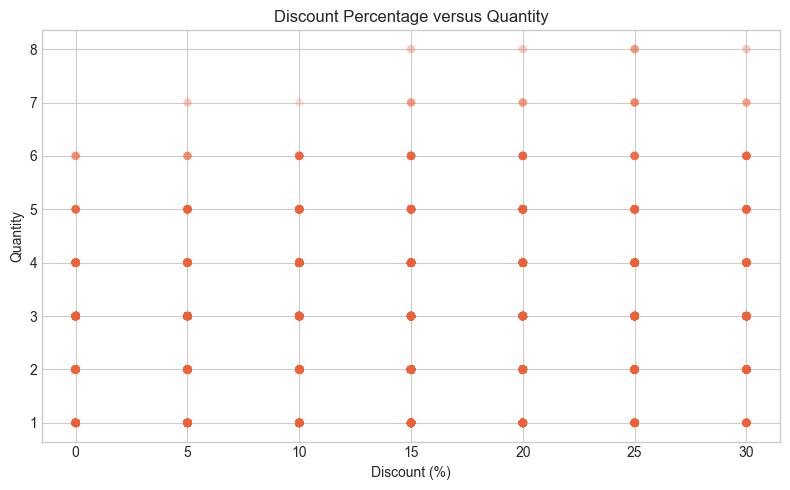

Pearson correlation: 0.234


In [ ]:
correlation = orders['discount_percent'].corr(orders['quantity'])

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(orders['discount_percent'], orders['quantity'], alpha=0.18, color='#F46036', edgecolors='none')
ax.set_title('Discount Percentage versus Quantity')
ax.set_xlabel('Discount (%)')
ax.set_ylabel('Quantity')
plt.tight_layout()
plt.show()

print(f'Pearson correlation: {correlation:.3f}')

### 3.4 Additional chart: return rate by product category

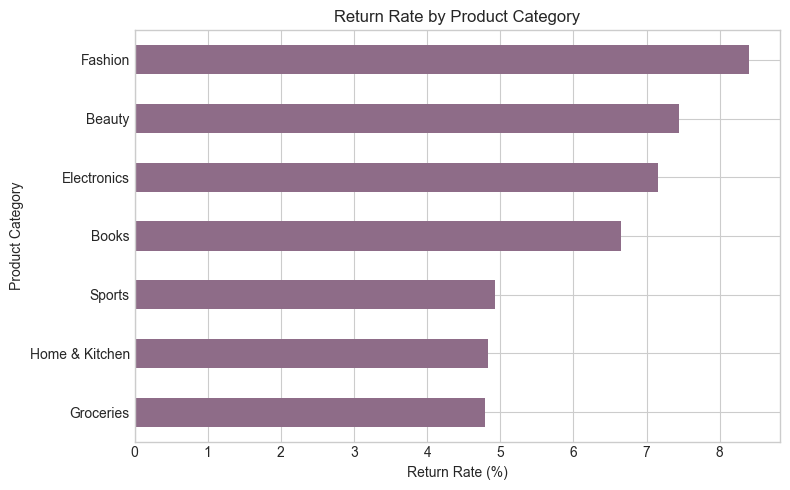

In [ ]:
ax = return_rate_by_category.sort_values().plot(kind='barh', figsize=(8, 5), color='#8E6C88')
ax.set_title('Return Rate by Product Category')
ax.set_xlabel('Return Rate (%)')
ax.set_ylabel('Product Category')
plt.tight_layout()
plt.show()

**Two evidence-based observations:**

1. Category revenue is concentrated at the top: **Electronics (PKR 15.41 million)** and **Home & Kitchen (PKR 14.07 million)** together generate about **49.63%** of all revenue, whereas Books produces only PKR 2.47 million.
2. Monthly revenue peaks in **May 2025 at PKR 3,474,650.06**. Discount and quantity have only a **weak positive correlation (r = 0.234)**, so higher discounts are associated with somewhat larger baskets but do not strongly determine quantity. The additional chart also shows Fashion has the highest category return rate at 8.40%.

# Task 4: Discover, Explain and Scale the Analysis

### 4.1 Analysis summary table

In [ ]:
summary_table = pd.DataFrame({
    'Check': [
        'Highest-revenue category',
        'Region with highest average order value',
        'Overall return rate',
        'Peak revenue month',
    ],
    'Result': [
        f'{revenue_by_category.index[0]} — PKR {revenue_by_category.iloc[0]:,.2f}',
        f'{region_aov.index[0]} — PKR {region_aov.iloc[0]:,.2f}',
        f'{orders["returned_flag"].mean() * 100:.2f}%',
        f'{monthly.idxmax()} — PKR {monthly.max():,.2f}',
    ],
    'Short interpretation': [
        'Electronics is the largest contributor to total sales revenue.',
        'Orders from Khyber Pakhtunkhwa have the highest mean monetary value.',
        'Approximately 6 out of every 100 orders are returned.',
        'May 2025 is the strongest month in the observed date range.',
    ],
})
display(summary_table)

,Check,Result,Short interpretation
0,Highest-revenue category,"Electronics — PKR 15,411,021.58",Electronics is the largest contributor to tota...
1,Region with highest average order value,"Khyber Pakhtunkhwa — PKR 10,370.28",Orders from Khyber Pakhtunkhwa have the highes...
2,Overall return rate,6.42%,Approximately 6 out of every 100 orders are re...
3,Peak revenue month,"2025-05 — PKR 3,474,650.06",May 2025 is the strongest month in the observe...


### 4.2 Investigation: Do lower customer ratings have a higher return rate?

,order_count,returned_orders,return_rate_percent
customer_rating,,,
1,10,4,40.00
2,149,31,20.81
3,980,103,10.51
4,2454,119,4.85
5,2407,128,5.32


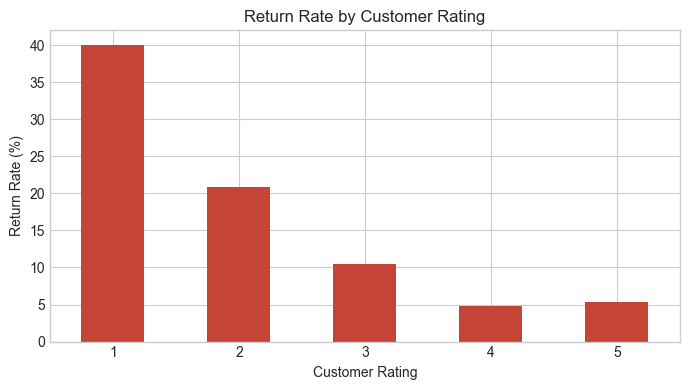

In [ ]:
rating_return_analysis = (orders.groupby('customer_rating')['returned_flag']
                          .agg(order_count='size', returned_orders='sum', return_rate='mean'))
rating_return_analysis['return_rate_percent'] = rating_return_analysis.pop('return_rate') * 100
display(rating_return_analysis)

ax = rating_return_analysis['return_rate_percent'].plot(kind='bar', figsize=(7, 4), color='#C44536')
ax.set_title('Return Rate by Customer Rating')
ax.set_xlabel('Customer Rating')
ax.set_ylabel('Return Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Answer:** Yes, lower ratings are associated with higher return rates. One-star orders have a **40.00%** return rate and two-star orders **20.81%**, compared with **4.85%** for four-star and **5.32%** for five-star orders. The one-star group contains only 10 orders, so its 40% estimate is less stable, but the overall decline from low to high ratings is strong evidence of a relationship.

### 4.3 Additional question: Which payment method has the highest average order value?

In [ ]:
payment_aov = (orders.groupby('payment_method')['total_amount']
               .agg(order_count='size', average_order_value_pkr='mean')
               .sort_values('average_order_value_pkr', ascending=False))
display(payment_aov)

,order_count,average_order_value_pkr
payment_method,,
Bank Transfer,372,"10,154.07"
Cash on Delivery,2516,"9,925.12"
Easypaisa/JazzCash,1382,"9,887.47"
Debit/Credit Card,1730,"9,815.08"


**Answer:** Bank Transfer has the highest average order value at **PKR 10,154.07**, followed by Cash on Delivery at PKR 9,925.12. The difference between the highest and lowest method (Debit/Credit Card, PKR 9,815.08) is only **PKR 338.98**, so payment method is not associated with a large practical difference in average order value.

### 4.4 Chunk-based revenue aggregation

In [ ]:
category_totals = {}
for chunk in pd.read_csv(data_path, chunksize=500):
    grouped = chunk.groupby('product_category')['total_amount'].sum()
    for category, value in grouped.items():
        category_totals[category] = category_totals.get(category, 0) + value

chunked_revenue = pd.Series(category_totals, name='chunked_revenue_pkr').sort_values(ascending=False)
display(chunked_revenue.to_frame())

chunk_check = chunked_revenue.sort_index().round(2).equals(revenue_by_category.sort_index().round(2))
print('Chunked totals match the full-data totals:', chunk_check)

,chunked_revenue_pkr
Electronics,"15,411,021.58"
Home & Kitchen,"14,068,389.08"
Fashion,"9,349,700.77"
Beauty,"8,171,233.78"
Sports,"5,987,947.19"
Groceries,"3,939,738.64"
Books,"2,465,474.49"


Chunked totals match the full-data totals: True


**Explanation:** Chunking reads only 500 rows at a time, aggregates each part, and adds the partial results. This limits peak memory use and makes the same analysis possible when the complete file is larger than available RAM. The chunked category totals match the full-data totals, confirming that the incremental aggregation is correct.

## Student Reflection

The most useful pattern is the sharp relationship between low ratings and returns: two-star orders return at 20.81%, compared with about 5% for four- and five-star orders. This suggests customer ratings can act as an early warning signal for return risk, although the very small one-star group should be interpreted cautiously.